# CatBoost Multi-Quantile Dashboard Model

This notebook trains the CatBoost interval model used by the dashboard. It reuses the exact cleaned modelling dataset, feature set, and train/test split exported from the main project notebook, then saves a model that returns a lower estimate, median estimate, and upper estimate.

## 1. Load Modelling Inputs

The exported files keep this notebook aligned with the final point-estimate model without repeating the full report workflow.

In [1]:
# Import core packages
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown

# Import modelling and evaluation tools
from catboost import CatBoostRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

# Project paths
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"

In [2]:
# Define input and output paths
MODEL_INPUT_DIR = DATA_DIR / "model_inputs"
MODEL_OUTPUT_PATH = MODELS_DIR / "catboost_used_car_price_quantile_model.pkl"

# Check that the main notebook export has been created
required_files = [
    MODEL_INPUT_DIR / "used_car_modelling_dataset.csv",
    MODEL_INPUT_DIR / "used_car_train_index.csv",
    MODEL_INPUT_DIR / "used_car_test_index.csv",
    MODEL_INPUT_DIR / "used_car_modelling_metadata.json",
]

missing_files = [str(path) for path in required_files if not path.exists()]

# Stop early with a clear message if the exported modelling files are missing
if missing_files:
    raise FileNotFoundError(
        "Run the modelling-data export cell in "
        "used_car_price_prediction_australia.ipynb before running this notebook. "
        f"Missing files: {missing_files}"
    )

In [3]:
# Load the exact modelling dataframe exported from the main notebook
df_model = pd.read_csv(
    MODEL_INPUT_DIR / "used_car_modelling_dataset.csv"
).set_index("modelling_index")

df_model.index = df_model.index.astype(int)

# Load the original train/test split indices
train_index = pd.read_csv(
    MODEL_INPUT_DIR / "used_car_train_index.csv"
)["modelling_index"].astype(int)

test_index = pd.read_csv(
    MODEL_INPUT_DIR / "used_car_test_index.csv"
)["modelling_index"].astype(int)

# Load the modelling metadata, including target and feature definitions
with open(MODEL_INPUT_DIR / "used_car_modelling_metadata.json", "r") as f:
    model_metadata = json.load(f)

model_metadata

{'target_col': 'price',
 'model_price_upper': 139818.00000000003,
 'catboost_numeric_features': ['year',
  'kilometres',
  'engine_size_litres',
  'fuel_consumption_per_100km',
  'cylinders',
  'doors',
  'seats'],
 'catboost_categorical_features': ['brand',
  'transmission',
  'body_type',
  'fuel_type',
  'drive_type',
  'state',
  'colour_ext',
  'model'],
 'catboost_features': ['year',
  'kilometres',
  'engine_size_litres',
  'fuel_consumption_per_100km',
  'cylinders',
  'doors',
  'seats',
  'brand',
  'transmission',
  'body_type',
  'fuel_type',
  'drive_type',
  'state',
  'colour_ext',
  'model'],
 'test_size': 0.2,
 'random_state': 42,
 'cv_folds': 5,
 'target_transform': 'log1p',
 'inverse_target_transform': 'expm1'}

## 2. Recreate Modelling Split

The same rows, target, predictors, and train/test split are used here as in the main CatBoost model.

In [4]:
# Extract target and feature definitions from the exported metadata
target_col = model_metadata["target_col"]
catboost_numeric_features = model_metadata["catboost_numeric_features"]
catboost_categorical_features = model_metadata["catboost_categorical_features"]
catboost_features = model_metadata["catboost_features"]

# Define the target variable
y = df_model[target_col].astype("float64").copy()

# Recreate the CatBoost predictor dataframe using the same feature set
X_catboost = df_model[catboost_features].copy()
X_catboost = X_catboost.astype("object").where(pd.notna(X_catboost), np.nan)
X_catboost[catboost_numeric_features] = X_catboost[catboost_numeric_features].astype("float64")

# Apply the same train/test split used in the main notebook
X_catboost_train = X_catboost.loc[train_index].copy()
X_catboost_test = X_catboost.loc[test_index].copy()

y_train = y.loc[train_index].copy()
y_test = y.loc[test_index].copy()

# Confirm the recreated modelling split
print(f"Training rows: {X_catboost_train.shape[0]:,}")
print(f"Test rows: {X_catboost_test.shape[0]:,}")
print(f"Features: {X_catboost_train.shape[1]:,}")

Training rows: 11,866
Test rows: 2,967
Features: 15


## 3. Train Multi-Quantile CatBoost

The model is trained on `log1p(price)`, matching the target strategy used in the main notebook. Predictions are converted back to dollars with `expm1`.

In [5]:
# Define dashboard valuation interval quantiles
QUANTILES = (0.05, 0.10, 0.50, 0.90, 0.95)
INTERVAL_DEFINITIONS = {
    "P10-P90": {
        "lower_col": "price_p10",
        "upper_col": "price_p90",
        "expected_coverage": 80.0,
    },
    "P05-P95": {
        "lower_col": "price_p05",
        "upper_col": "price_p95",
        "expected_coverage": 90.0,
    },
}

print("Expected coverage: P10-P90 = 80%, P05-P95 = 90%")

# CatBoost receives categorical feature positions after preprocessing
catboost_categorical_indices = list(
    range(len(catboost_numeric_features), len(catboost_features))
)


def build_catboost_preprocessor():
    """Create a fresh CatBoost preprocessor for each training run."""
    # Median imputation matches the main notebook's CatBoost numeric preprocessing
    numeric_preprocessor = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    # Missing categorical values are kept as an explicit category
    categorical_preprocessor = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing"))
    ])

    # Keep numeric columns first and categorical columns second for CatBoost indices
    return ColumnTransformer(transformers=[
        ("numeric", numeric_preprocessor, catboost_numeric_features),
        ("categorical", categorical_preprocessor, catboost_categorical_features),
    ])


def fit_catboost_multiquantile(X_train, y_train, quantiles=QUANTILES):
    """Fit a CatBoost model that predicts multiple price quantiles."""
    # Fit preprocessing on the current training data only
    preprocessor = build_catboost_preprocessor()
    X_train_prepared = preprocessor.fit_transform(X_train)

    # CatBoost expects MultiQuantile alpha values as a comma-separated string
    alpha_string = ",".join(str(q) for q in quantiles)

    # Train the interval model on log-transformed prices for consistency
    model = CatBoostRegressor(
        loss_function=f"MultiQuantile:alpha={alpha_string}",
        random_state=42,
        verbose=False,
    )

    model.fit(
        X_train_prepared,
        np.log1p(y_train),
        cat_features=catboost_categorical_indices,
    )

    # Store the fitted objects and metadata needed by the dashboard
    return {
        "preprocessor": preprocessor,
        "model": model,
        "feature_names": catboost_features,
        "numeric_features": catboost_numeric_features,
        "categorical_features": catboost_categorical_features,
        "categorical_indices": catboost_categorical_indices,
        "quantiles": quantiles,
        "target_transform": "log1p",
        "inverse_target_transform": "expm1",
    }


def predict_price_interval(model_bundle, X):
    """Return lower, median, and upper price estimates in dollars."""
    # Apply the fitted preprocessing from the model bundle
    X_prepared = model_bundle["preprocessor"].transform(
        X[model_bundle["feature_names"]]
    )

    # CatBoost returns one prediction per requested quantile
    log_predictions = np.asarray(model_bundle["model"].predict(X_prepared))

    if log_predictions.ndim == 1:
        log_predictions = log_predictions.reshape(-1, len(model_bundle["quantiles"]))

    # Convert predictions back from log-price to dollar-price scale
    price_predictions = np.expm1(log_predictions)
    price_predictions = np.clip(price_predictions, 0, None)

    # Ensure the interval remains ordered if quantile crossing occurs
    price_predictions = np.maximum.accumulate(price_predictions, axis=1)

    # Label each prediction column by percentile
    columns = [
        f"price_p{int(q * 100):02d}"
        for q in model_bundle["quantiles"]
    ]

    return pd.DataFrame(price_predictions, columns=columns, index=X.index)

Expected coverage: P10-P90 = 80%, P05-P95 = 90%


## 4. Final Test Evaluation

The final interval model is fitted on the full training split and evaluated once on the held-out test split.

In [6]:
# Fit the final dashboard model on the full training split
dashboard_quantile_model = fit_catboost_multiquantile(
    X_catboost_train,
    y_train,
)

# Generate quantile predictions for the held-out test split
test_interval_predictions = predict_price_interval(
    dashboard_quantile_model,
    X_catboost_test,
)

# Combine actual prices with interval predictions for evaluation
test_prediction_results = pd.concat([
    y_test.rename("actual_price"),
    test_interval_predictions,
], axis=1)

# Evaluate overall point-estimate accuracy using the median prediction
test_median_pred = test_prediction_results["price_p50"]

median_prediction_metrics = pd.DataFrame({
    "MAE": [mean_absolute_error(y_test, test_median_pred)],
    "MAPE": [mean_absolute_percentage_error(y_test, test_median_pred) * 100],
    "RMSE": [root_mean_squared_error(y_test, test_median_pred)],
    "R-squared": [r2_score(y_test, test_median_pred)],
}, index=["CatBoost MultiQuantile"])

display(Markdown("### Overall median prediction metrics"))
display(median_prediction_metrics)

# Compare the two candidate dashboard market ranges
interval_comparison_rows = []

for interval_name, interval_info in INTERVAL_DEFINITIONS.items():
    lower_pred = test_prediction_results[interval_info["lower_col"]]
    upper_pred = test_prediction_results[interval_info["upper_col"]]
    interval_width = upper_pred - lower_pred
    interval_width_pct_actual = (interval_width / test_prediction_results["actual_price"]) * 100
    actual_coverage = (
        (test_prediction_results["actual_price"] >= lower_pred) &
        (test_prediction_results["actual_price"] <= upper_pred)
    ).mean() * 100

    interval_comparison_rows.append({
        "Interval": interval_name,
        "Expected Coverage (%)": interval_info["expected_coverage"],
        "Actual Test Coverage (%)": actual_coverage,
        "Coverage Gap (pp)": actual_coverage - interval_info["expected_coverage"],
        "Mean Interval Width": interval_width.mean(),
        "Median Interval Width": interval_width.median(),
        "Mean Interval Width (% Actual Price)": interval_width_pct_actual.mean(),
        "Median Interval Width (% Actual Price)": interval_width_pct_actual.median(),
    })

interval_comparison = pd.DataFrame(interval_comparison_rows).set_index("Interval")

display(Markdown("### Candidate dashboard interval comparison"))
display(interval_comparison)

# Prefer P05-P95 if coverage improves without making the range impractically wide
p10_p90_gap = abs(interval_comparison.loc["P10-P90", "Coverage Gap (pp)"])
p05_p95_gap = abs(interval_comparison.loc["P05-P95", "Coverage Gap (pp)"])
p10_p90_coverage = interval_comparison.loc["P10-P90", "Actual Test Coverage (%)"]
p05_p95_coverage = interval_comparison.loc["P05-P95", "Actual Test Coverage (%)"]
p10_p90_width_pct = interval_comparison.loc["P10-P90", "Mean Interval Width (% Actual Price)"]
p05_p95_width_pct = interval_comparison.loc["P05-P95", "Mean Interval Width (% Actual Price)"]
p05_p95_width_ratio = p05_p95_width_pct / p10_p90_width_pct

MAX_P05_P95_WIDTH_RATIO = 2.0

if (
    (p05_p95_gap <= p10_p90_gap or p05_p95_coverage >= p10_p90_coverage) and
    p05_p95_width_ratio <= MAX_P05_P95_WIDTH_RATIO
):
    preferred_dashboard_interval = "P05-P95"
    dashboard_interval_note = (
        "P05-P95 is selected as the preferred dashboard market range because it gives "
        "more reasonable coverage while keeping the interval width within the lightweight width check."
    )
else:
    preferred_dashboard_interval = "P10-P90"
    dashboard_interval_note = (
        "P10-P90 is selected because P05-P95 does not improve coverage enough, "
        "or it makes the dashboard range too wide for this lightweight valuation view."
    )

display(Markdown(dashboard_interval_note))


### Overall median prediction metrics

,MAE,MAPE,RMSE,R-squared
CatBoost MultiQuantile,4068.114,13.455,6998.616,0.874


### Candidate dashboard interval comparison

,Expected Coverage (%),Actual Test Coverage (%),Coverage Gap (pp),Mean Interval Width,Median Interval Width,Mean Interval Width (% Actual Price),Median Interval Width (% Actual Price)
Interval,,,,,,,
P10-P90,80.000,74.857,-5.143,11130.476,8697.445,38.555,33.853
P05-P95,90.000,85.305,-4.695,14711.464,11535.910,51.560,44.433


P05-P95 is selected as the preferred dashboard market range because it gives more reasonable coverage while keeping the interval width within the lightweight width check.

In [7]:
# Add row-level diagnostics for the chosen dashboard interval
chosen_interval_info = INTERVAL_DEFINITIONS[preferred_dashboard_interval]
chosen_lower_col = chosen_interval_info["lower_col"]
chosen_upper_col = chosen_interval_info["upper_col"]

test_prediction_results["inside_chosen_interval"] = (
    (test_prediction_results["actual_price"] >= test_prediction_results[chosen_lower_col]) &
    (test_prediction_results["actual_price"] <= test_prediction_results[chosen_upper_col])
)
test_prediction_results["chosen_interval_width"] = (
    test_prediction_results[chosen_upper_col] - test_prediction_results[chosen_lower_col]
)
test_prediction_results["chosen_interval_width_pct_actual"] = (
    test_prediction_results["chosen_interval_width"] /
    test_prediction_results["actual_price"]
) * 100


## 5. Coverage by Actual Price Band

This section checks whether the chosen dashboard interval has reasonable coverage across lower- and higher-priced vehicles.

In [8]:
# Group test predictions into quantile-based actual-price bands
test_prediction_results["actual_price_band"] = pd.qcut(
    test_prediction_results["actual_price"],
    q=5,
    duplicates="drop",
)

# Calculate coverage and interval width by actual-price band for the chosen interval
coverage_by_price_band = (
    test_prediction_results
    .groupby("actual_price_band", observed=True)
    .agg(
        listings=("actual_price", "size"),
        mean_actual_price=("actual_price", "mean"),
        actual_coverage=("inside_chosen_interval", "mean"),
        mean_interval_width=("chosen_interval_width", "mean"),
        median_interval_width=("chosen_interval_width", "median"),
        mean_interval_width_pct_actual=("chosen_interval_width_pct_actual", "mean"),
        median_interval_width_pct_actual=("chosen_interval_width_pct_actual", "median"),
    )
)

coverage_by_price_band["Price Band"] = [
    f"${interval.left / 1000:,.0f}k-${interval.right / 1000:,.0f}k"
    for interval in coverage_by_price_band.index
]
coverage_by_price_band["Interval"] = preferred_dashboard_interval
coverage_by_price_band["Expected Coverage (%)"] = chosen_interval_info["expected_coverage"]
coverage_by_price_band["Actual Coverage (%)"] = coverage_by_price_band["actual_coverage"] * 100
coverage_by_price_band["Coverage Gap (pp)"] = (
    coverage_by_price_band["Actual Coverage (%)"] -
    coverage_by_price_band["Expected Coverage (%)"]
)

coverage_by_price_band_display = coverage_by_price_band[
    [
        "Price Band",
        "Interval",
        "listings",
        "mean_actual_price",
        "Expected Coverage (%)",
        "Actual Coverage (%)",
        "Coverage Gap (pp)",
        "mean_interval_width",
        "median_interval_width",
        "mean_interval_width_pct_actual",
        "median_interval_width_pct_actual",
    ]
]



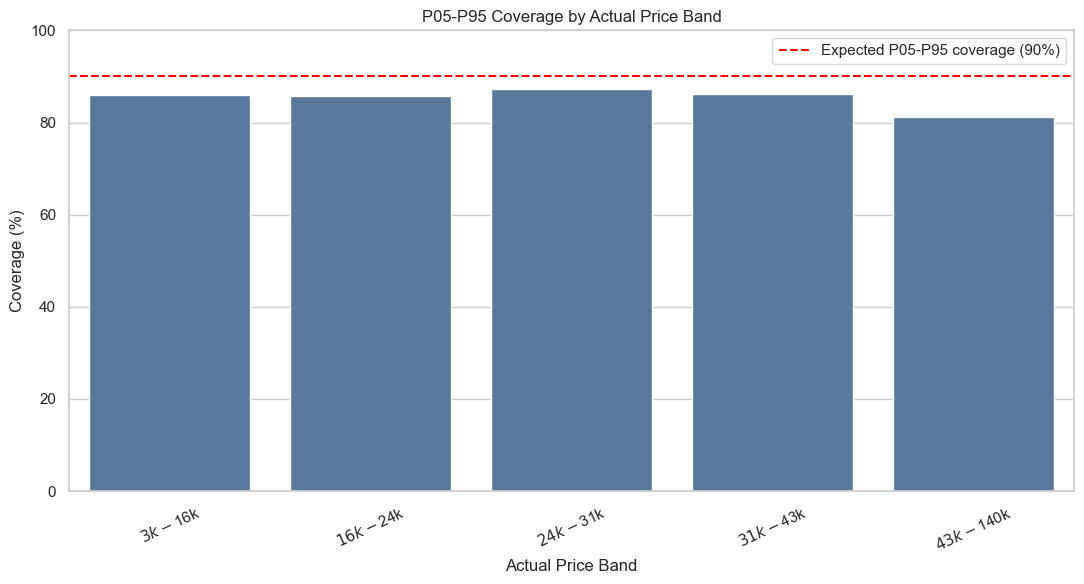

In [9]:
# Plot chosen interval coverage by price band against the expected coverage line
coverage_plot_data = coverage_by_price_band_display.copy()

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=coverage_plot_data,
    x="Price Band",
    y="Actual Coverage (%)",
    color="#4C78A8",
)
ax.axhline(
    chosen_interval_info["expected_coverage"],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Expected {preferred_dashboard_interval} coverage ({chosen_interval_info['expected_coverage']:.0f}%)",
)
ax.set_title(f"{preferred_dashboard_interval} Coverage by Actual Price Band")
ax.set_xlabel("Actual Price Band")
ax.set_ylabel("Coverage (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=25)
ax.legend()
plt.tight_layout()
plt.show()


Coverage is reasonably consistent across most price bands, but the highest-priced vehicles still show lower coverage. This likely reflects greater variation in trim, variant, condition, optional packages, and other pricing factors that are not fully captured in the current modelling dataset.

In [10]:
# Create a compact sample of dashboard interval predictions
example_predictions = test_prediction_results[
    [
        "actual_price",
        "price_p50",
        "price_p05",
        "price_p95",
        "inside_chosen_interval",
        "chosen_interval_width",
    ]
].head(10).copy()

example_predictions = example_predictions.rename(columns={
    "price_p50": "predicted_price_p50",
    "price_p05": "lower_bound_p05",
    "price_p95": "upper_bound_p95",
})

example_predictions["median_absolute_error"] = (
    example_predictions["actual_price"] -
    example_predictions["predicted_price_p50"]
).abs()

example_predictions = example_predictions[
    [
        "actual_price",
        "predicted_price_p50",
        "lower_bound_p05",
        "upper_bound_p95",
        "inside_chosen_interval",
        "median_absolute_error",
        "chosen_interval_width",
    ]
]

dollar_cols = [
    "actual_price",
    "predicted_price_p50",
    "lower_bound_p05",
    "upper_bound_p95",
    "median_absolute_error",
    "chosen_interval_width",
]

display(example_predictions.style.format({col: "${:,.0f}" for col in dollar_cols}))


,actual_price,predicted_price_p50,lower_bound_p05,upper_bound_p95,inside_chosen_interval,median_absolute_error,chosen_interval_width
modelling_index,,,,,,,
2629,"$8,499","$10,317","$7,474","$13,207",True,"$1,818","$5,733"
4103,"$22,890","$21,853","$16,389","$29,636",True,"$1,037","$13,247"
9605,"$12,499","$12,976","$10,734","$16,051",True,$477,"$5,317"
7163,"$37,990","$37,294","$33,388","$41,767",True,$696,"$8,379"
14945,"$19,988","$24,456","$16,122","$30,811",True,"$4,468","$14,689"
381,"$26,888","$21,072","$14,579","$32,445",True,"$5,816","$17,867"
4530,"$19,990","$25,268","$22,137","$29,710",False,"$5,278","$7,573"
11511,"$54,990","$53,892","$45,275","$76,501",True,"$1,098","$31,226"
305,"$32,980","$32,678","$30,310","$38,757",True,$302,"$8,447"


## 6. Save Dashboard Model

The saved object contains the fitted preprocessor, fitted CatBoost model, feature metadata, quantile settings, preferred dashboard interval, and evaluation results.

In [11]:
# Ensure the model output directory exists
MODEL_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Add evaluation metadata to the saved dashboard model bundle
dashboard_quantile_model["metadata"] = model_metadata
dashboard_quantile_model["median_prediction_metrics"] = median_prediction_metrics.to_dict()
dashboard_quantile_model["interval_comparison"] = interval_comparison.to_dict()
dashboard_quantile_model["preferred_dashboard_interval"] = preferred_dashboard_interval

# Save the trained model bundle for the dashboard to load
joblib.dump(dashboard_quantile_model, MODEL_OUTPUT_PATH)

print(f"Saved dashboard quantile model to: {MODEL_OUTPUT_PATH}")


Saved dashboard quantile model to: c:\Users\User\OneDrive\Desktop\Coding\Python\data_science_projects\used-car-price-prediction\models\catboost_used_car_price_quantile_model.pkl
